# aibl full preprocessing driver

this driver uses qc-passed raw t1 3d nifti files and saves anonymous aggregate qc information plus no more than three visual qc examples.


In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'SkullStrippingProject']
PROJECT_ROOT = next(path for path in candidates if (path / 'src' / 'skullstrip_pipeline').exists())
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from skullstrip_pipeline.driver import run_dataset
from skullstrip_pipeline.reporting import build_dataset_qc_report, save_anonymous_qc_examples, save_dataset_qc_summary_plot

DATASET = 'AIBL'
MAX_FILES = None
REPLACE = False
SAVE_QC_PLOTS = True
MAX_QC_PLOTS = 3
GPU_PHYSICAL_ID = 2

print(f'{DATASET.lower()} settings: max files={MAX_FILES}, replace={REPLACE}, gpu={GPU_PHYSICAL_ID}')


aibl settings: max files=None, replace=False, gpu=2


## preprocessing


In [2]:
status = run_dataset(
    DATASET,
    max_files=MAX_FILES,
    replace=REPLACE,
    save_qc_plots=SAVE_QC_PLOTS,
    max_qc_plots=MAX_QC_PLOTS,
    gpu_physical_id=GPU_PHYSICAL_ID,
    progress=True,
)


AIBL: selected 0 scans; already successful 1311; gpu 2


## qc report and sanity checks


In [3]:
qc_report = build_dataset_qc_report(status)

print('manifest status')
display(qc_report['status'])
print('stage qc summary')
display(qc_report['stage_qc'])
print('final-output sanity checks')
display(qc_report['sanity_checks'])
print('qc metric distribution for successful scans')
display(qc_report['metric_summary'])
print('final spatial geometry')
display(qc_report['geometry'])

if not qc_report['failures'].empty:
    print('anonymous failure summary')
    display(qc_report['failures'])
else:
    print('anonymous failure summary: no failures')


manifest status


,status,count,percent
0,success,1311,100.0


stage qc summary


,stage,passed,failed,not_evaluated,pass_rate_percent
0,SynthStrip brain mask,1311,0,0,100.0
1,mask-guided N4,1311,0,0,100.0
2,native skull stripping,1311,0,0,100.0
3,affine MNI registration,1311,0,0,100.0
4,brain-masked Z-score,1311,0,0,100.0


final-output sanity checks


...

qc metric distribution for successful scans


,metric,unit,count,median,p05,p95,minimum,maximum,target
0,brain-mask volume,mL,1311,1519.180573,1325.023055,1785.291881,1152.447786,1952.515931,150 to 2500
1,template overlap,fraction,1311,0.987572,0.964627,0.997037,0.852888,0.999175,>= 0.85
2,centroid distance,mm,1311,2.608933,0.647407,9.048116,0.102977,20.481751,<= 30
3,normalized brain mean,Z,1311,0.000000,-0.000000,0.000000,-0.000000,0.000000,about 0
4,normalized brain standard deviation,Z,1311,1.000000,1.000000,1.000000,1.000000,1.000000,about 1
5,normalized background maximum,absolute Z,1311,0.000000,0.000000,0.000000,0.000000,0.000000,0


final spatial geometry


,property,value,count
0,final shape,182x218x182,1311
1,final spacing (mm),1x1x1,1311


anonymous failure summary: no failures


## saved qc plots


aggregate qc plot saved: Processed/MRI/AIBL/qc_examples/qc_summary.png
anonymous visual qc plots saved: 3 of maximum 3
list_position is the 1-based row number in the dataset preprocessing manifest


,sample_number,list_position,plot_path
0,1,129,Processed/MRI/AIBL/qc_examples/qc_sample_001.png
1,2,388,Processed/MRI/AIBL/qc_examples/qc_sample_002.png
2,3,405,Processed/MRI/AIBL/qc_examples/qc_sample_003.png


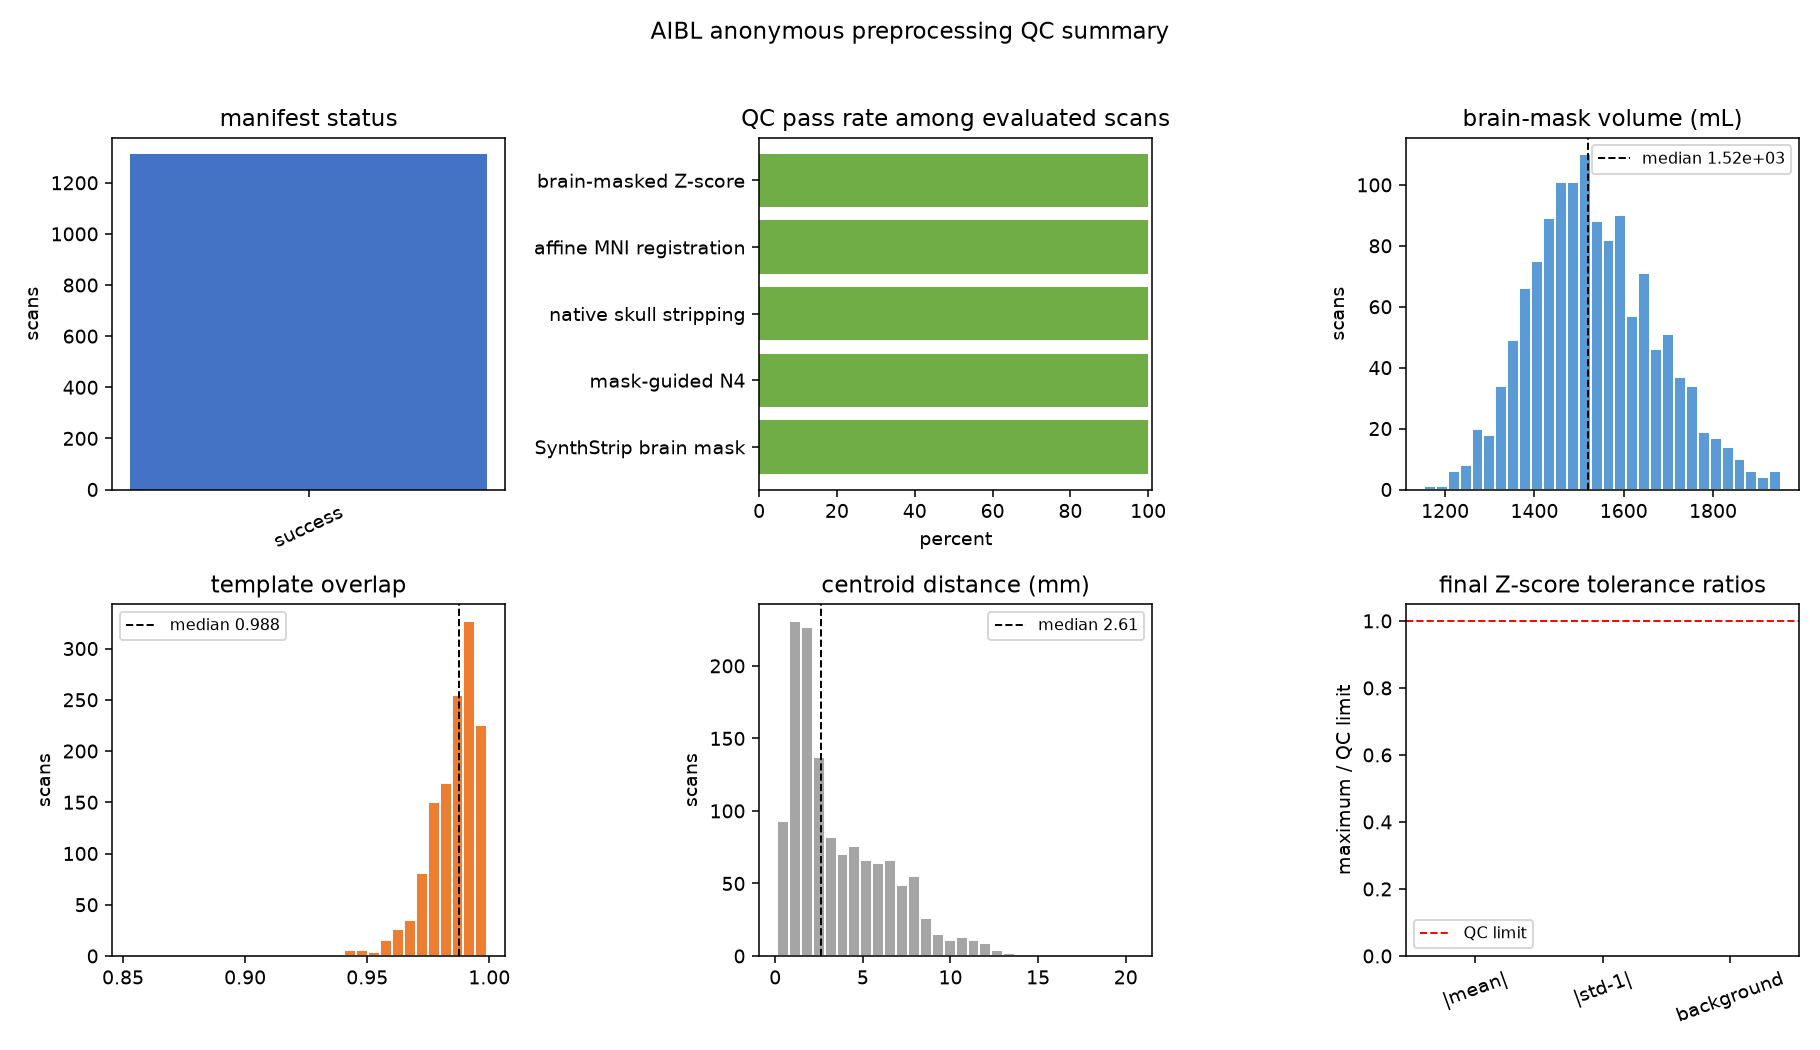

In [4]:
summary_plot = save_dataset_qc_summary_plot(status, DATASET)
visual_selection = save_anonymous_qc_examples(status, DATASET, MAX_QC_PLOTS)

print(f'aggregate qc plot saved: {summary_plot.relative_to(PROJECT_ROOT.parent)}')
print(f'anonymous visual qc plots saved: {len(visual_selection)} of maximum {MAX_QC_PLOTS}')
print('list_position is the 1-based row number in the dataset preprocessing manifest')
display(visual_selection)
display(Image(filename=str(summary_plot)))


## final check


In [5]:
success_count = int(status['status'].eq('success').sum())
failed_count = int(status['status'].isin(['failed', 'qc_failed']).sum())
unfinished_count = int(status['status'].ne('success').sum())
print(f'aibl final status: success={success_count} of {len(status)}, unfinished={unfinished_count}, failed={failed_count}')
if unfinished_count:
    raise RuntimeError(f'aibl has {unfinished_count} scans requiring checkpoint retry')
print('aibl preprocessing and automated qc finished')


aibl final status: success=1311 of 1311, unfinished=0, failed=0
aibl preprocessing and automated qc finished
